In [34]:
#importing libraries 
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [35]:
data = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [36]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [37]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [38]:
data.shape

(7043, 21)

In [39]:
# transform TotalCharges to numeric
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"] , errors="coerce")

In [40]:
data.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7032.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2283.300441,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.771362,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,401.450000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3794.737500,NaN


In [41]:
categorical_cols = data.select_dtypes(exclude = ["number"]).drop(["customerID"] , axis =1).columns.tolist()
categorical_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [42]:
quantity_cols = data.select_dtypes(include = ["number"]).columns.to_list() 
quantity_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

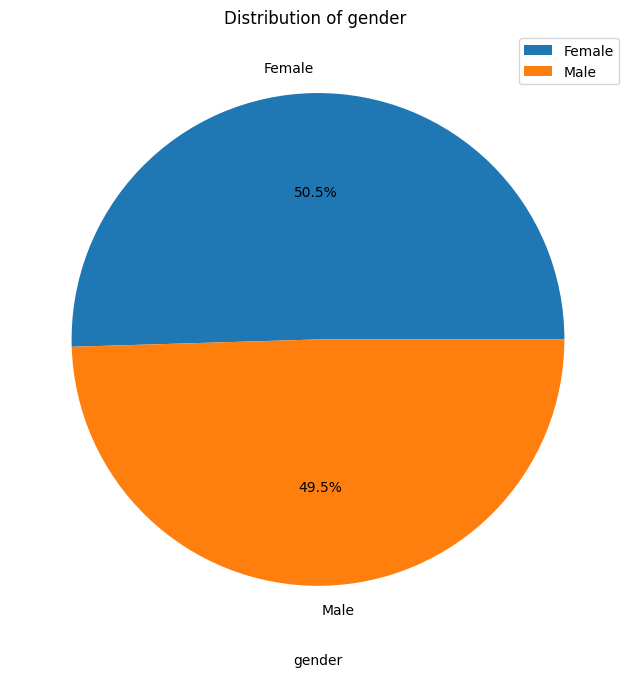

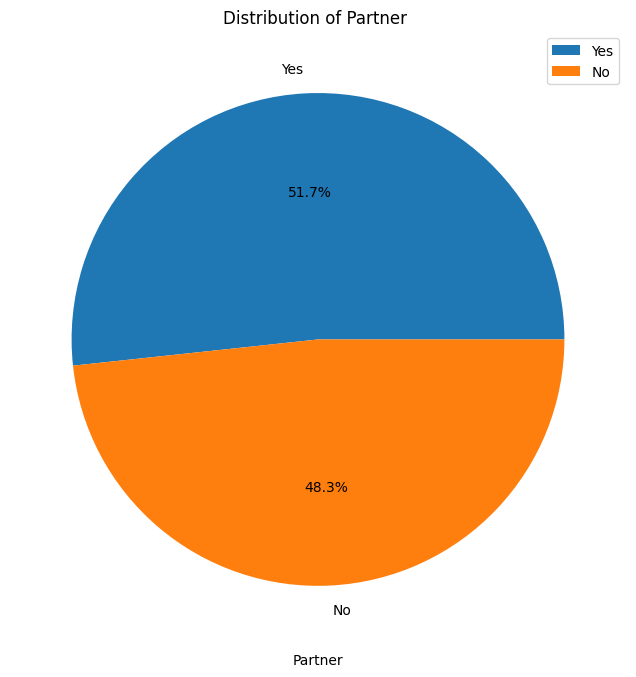

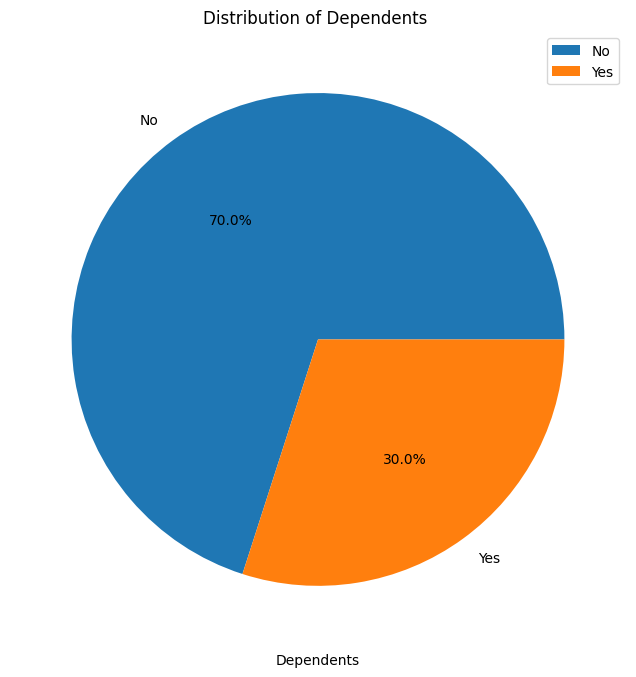

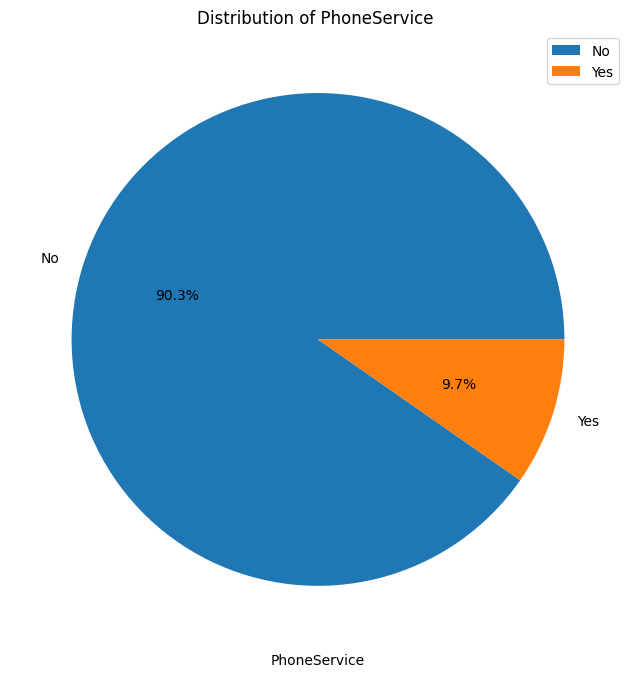

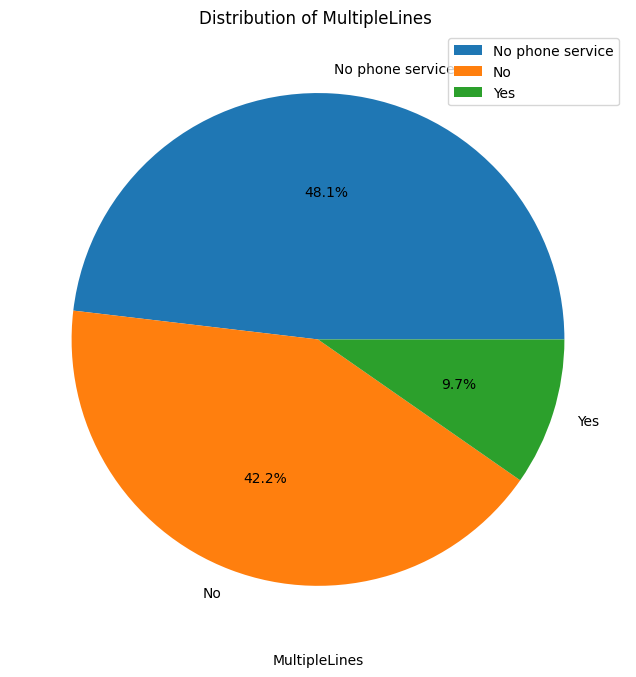

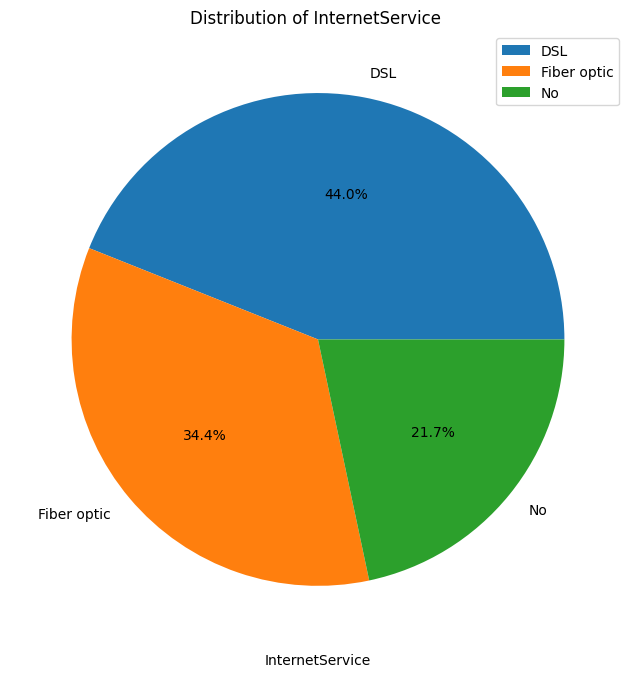

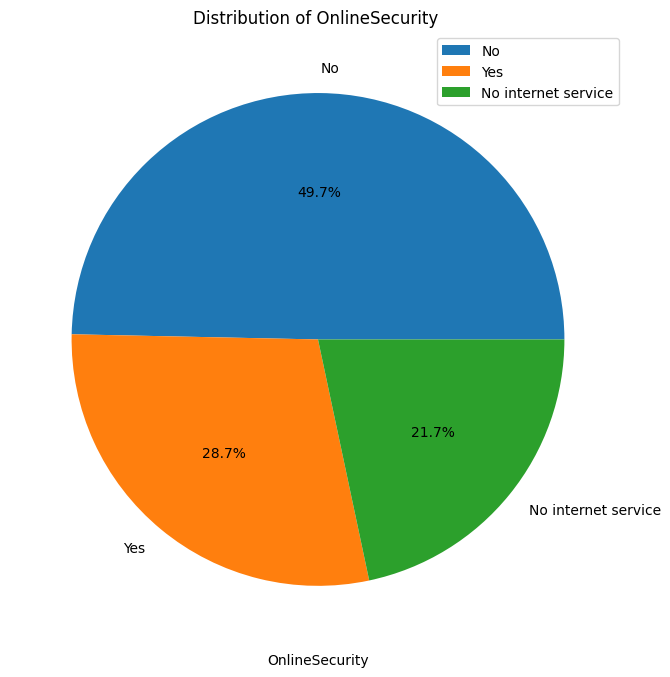

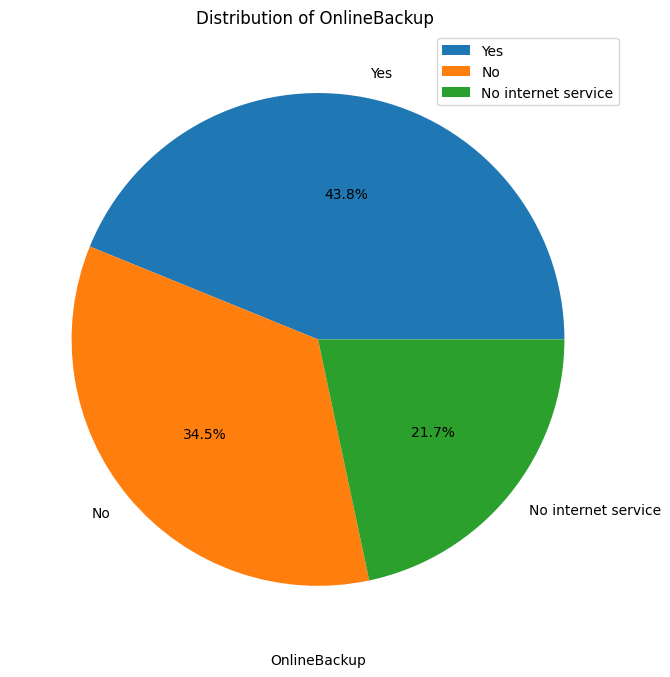

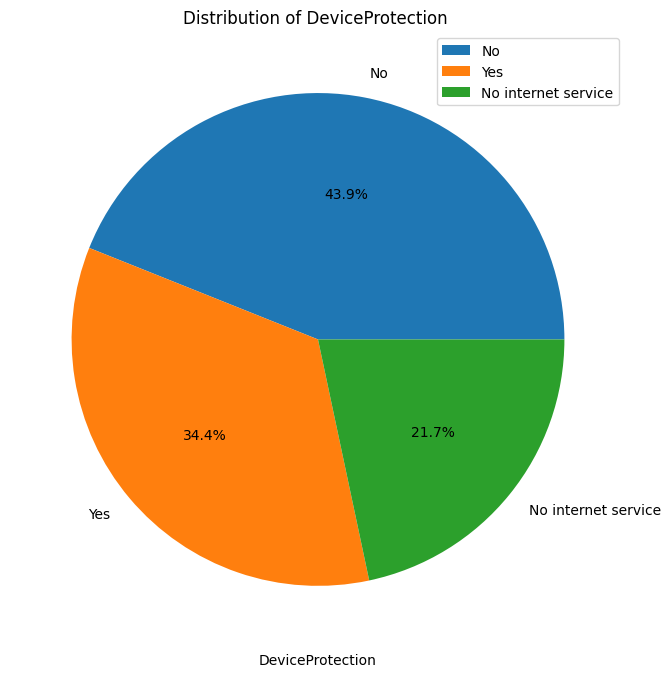

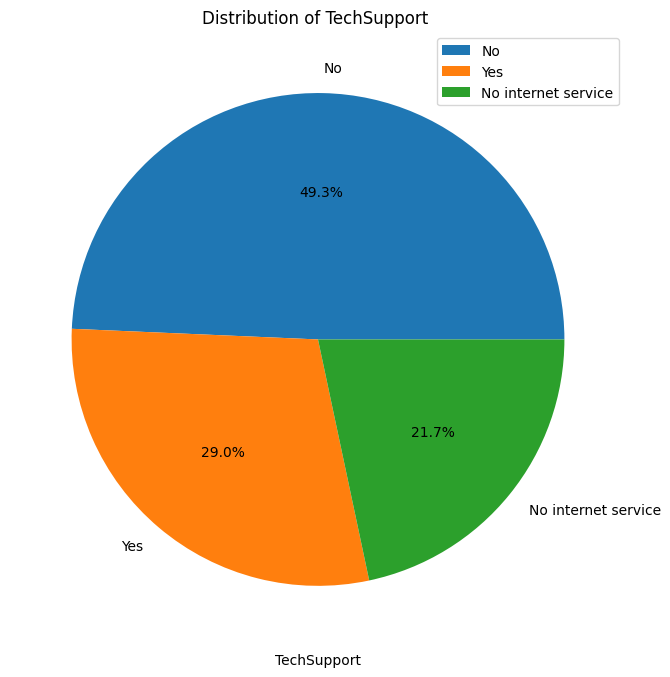

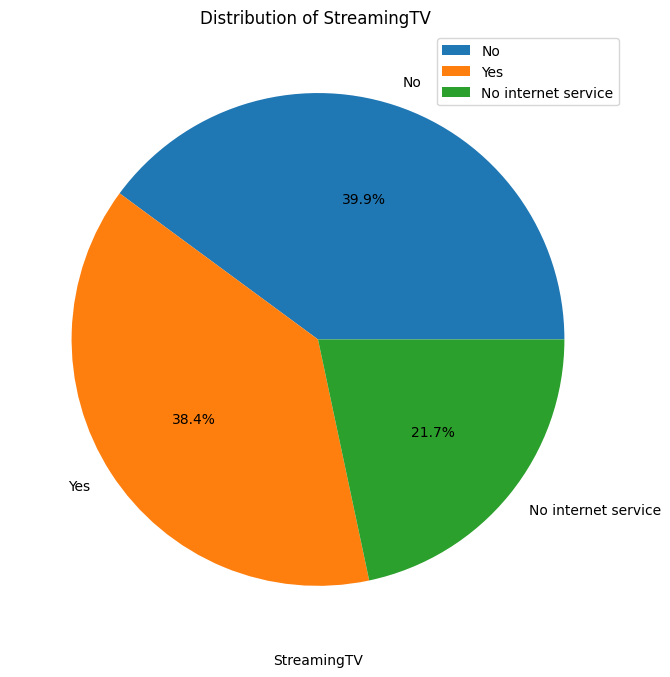

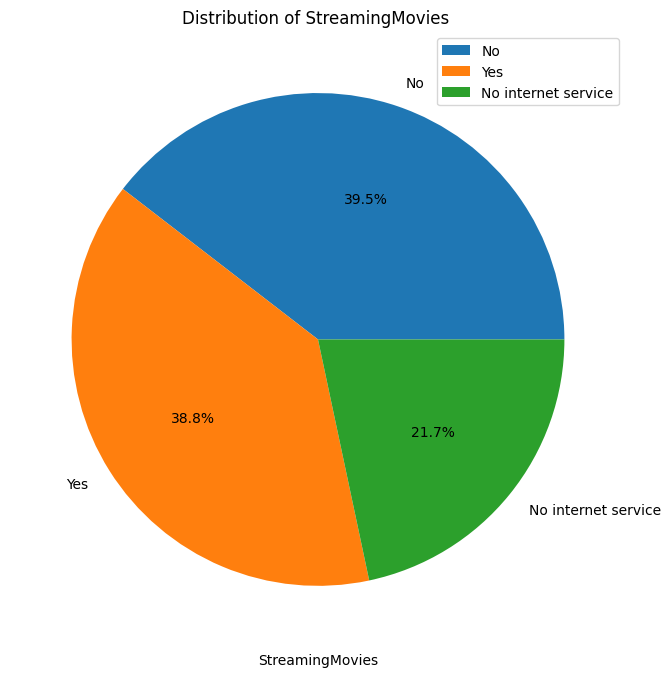

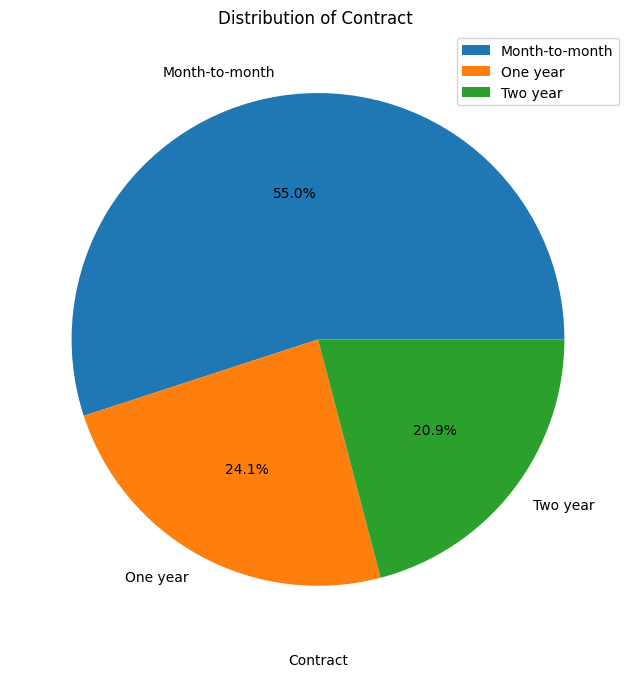

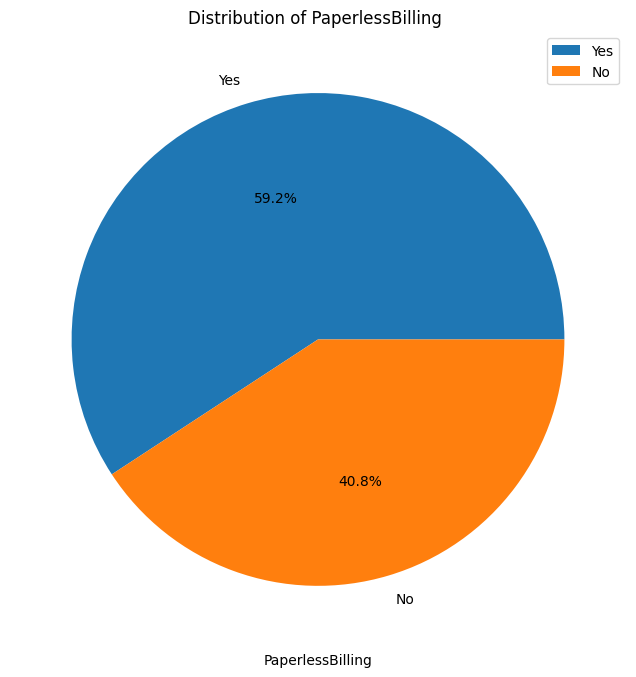

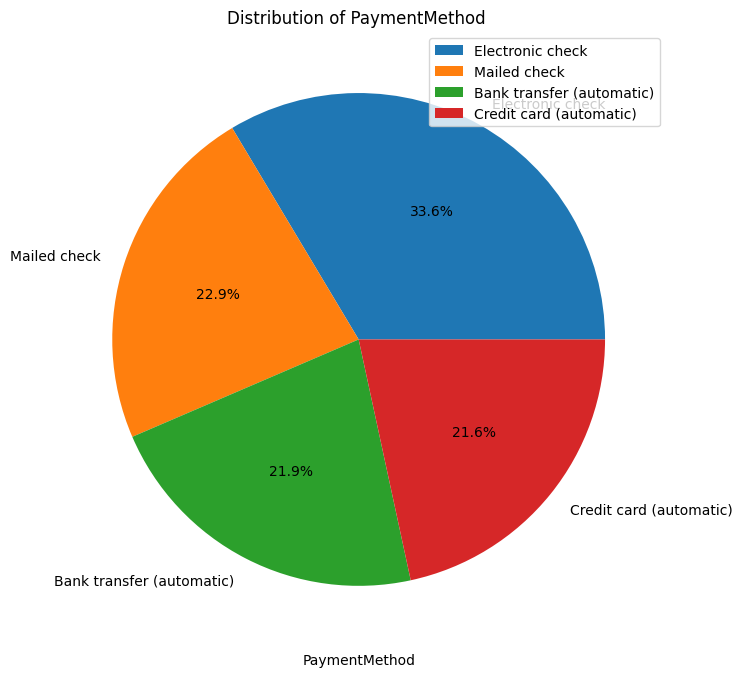

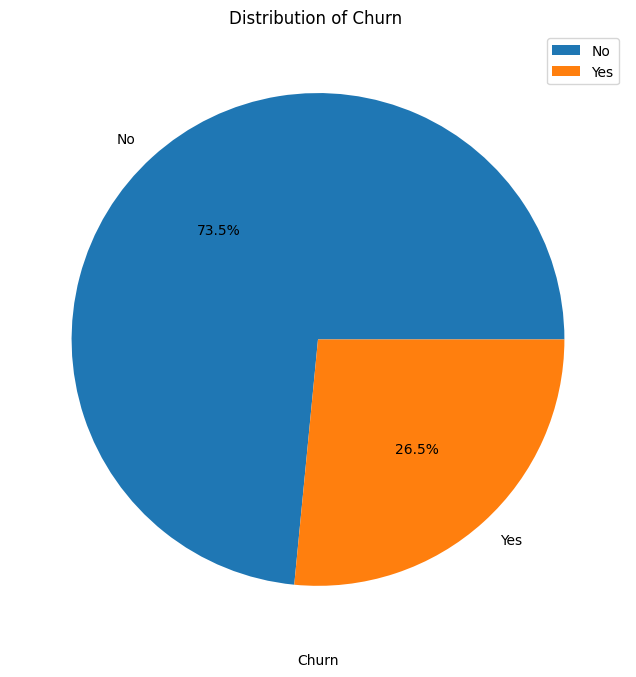

In [43]:
# Distribution of categorical variables
for i in categorical_cols:
    plt.figure(figsize=(12, 8))
    plt.pie(x = data[i].value_counts(), labels =data[i].unique(), autopct = "%1.1f%%", data = data )
    plt.title(f"Distribution of {i} ")
    plt.xlabel(i)
    plt.legend(labels = data[i].unique(), loc="upper right")



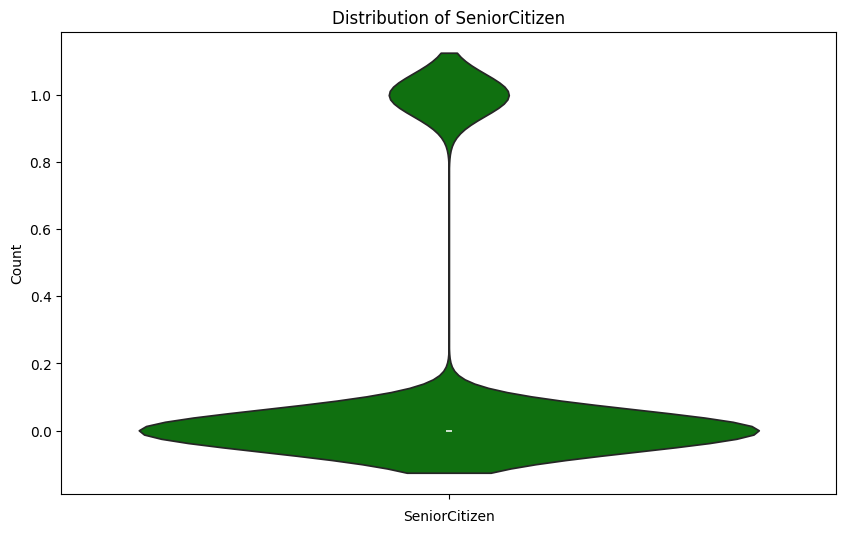

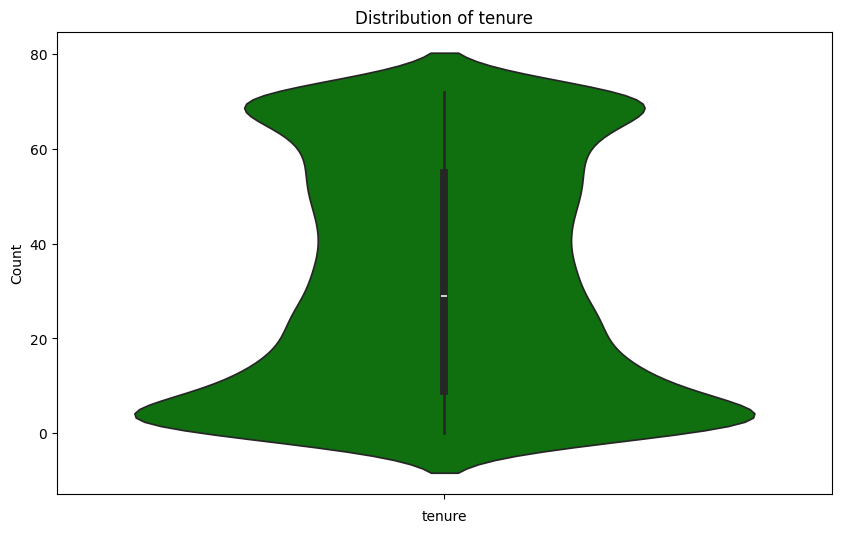

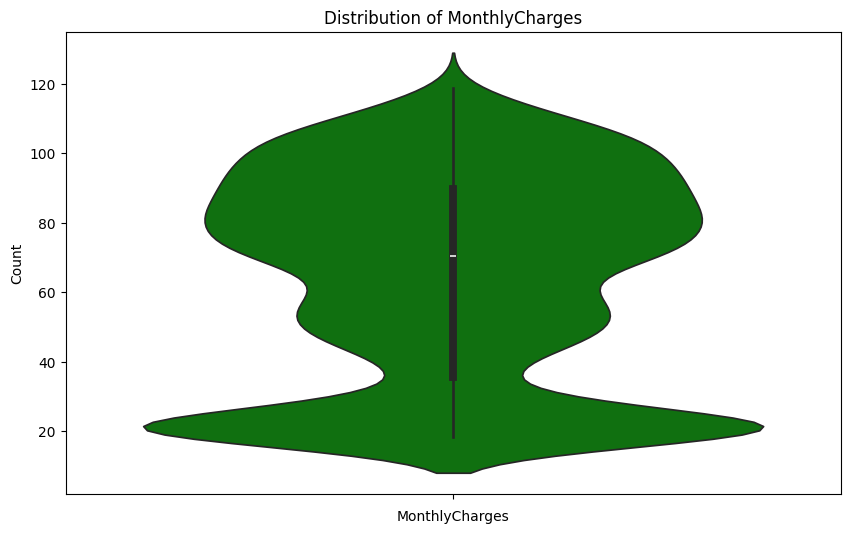

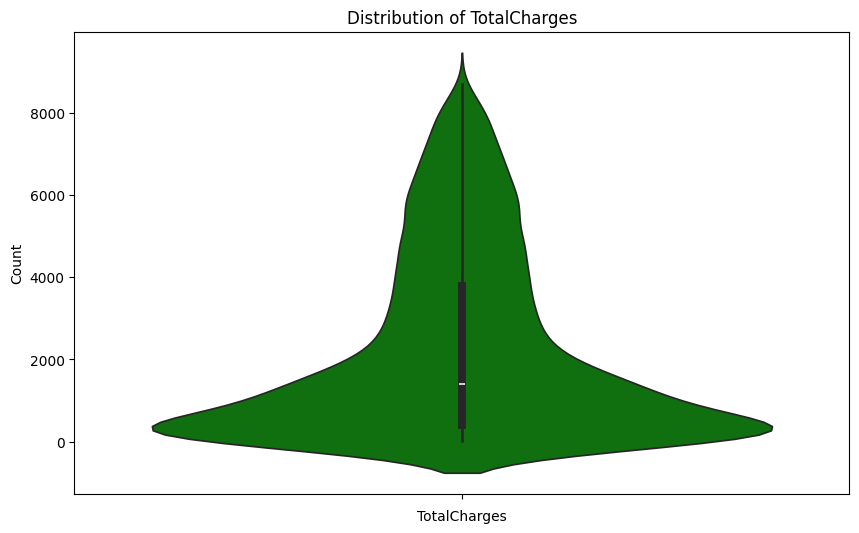

In [44]:
# Distribution of Senior Citizens, Tenure, and Monthly Charges
for i in quantity_cols:
    plt.figure(figsize=(10, 6))
    sns.violinplot(data[i] , fill=True , color = "green")
    plt.title(f"Distribution of {i}")
    plt.xlabel(i)
    plt.ylabel("Count")

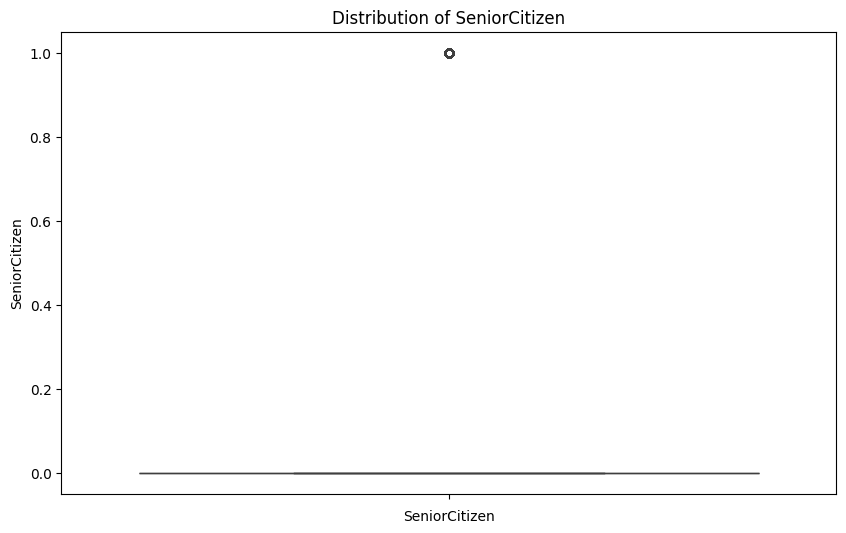

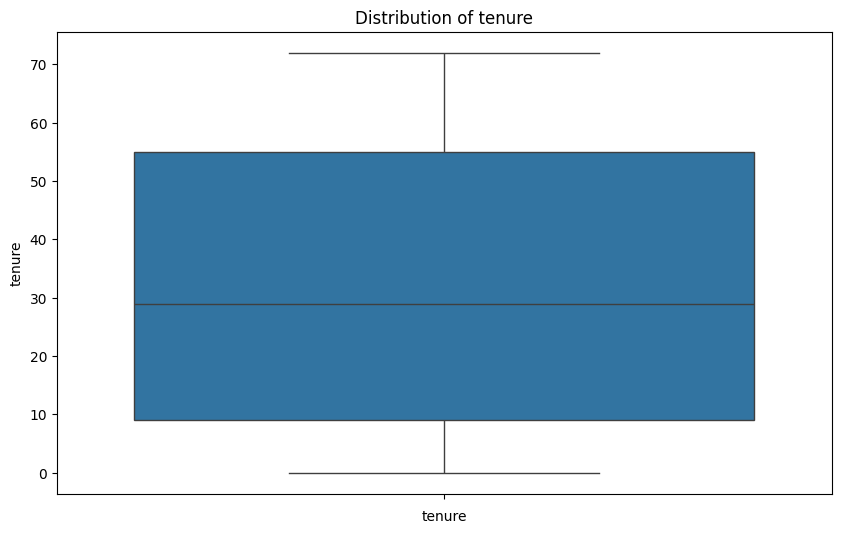

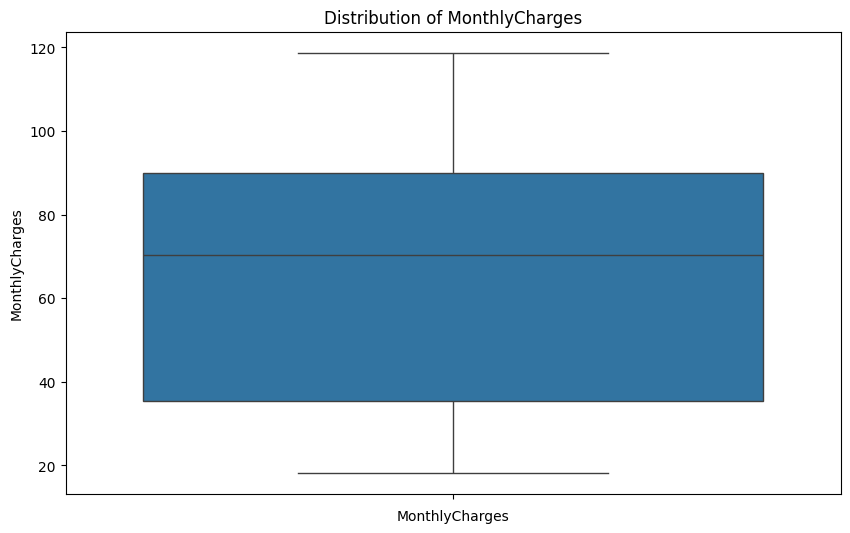

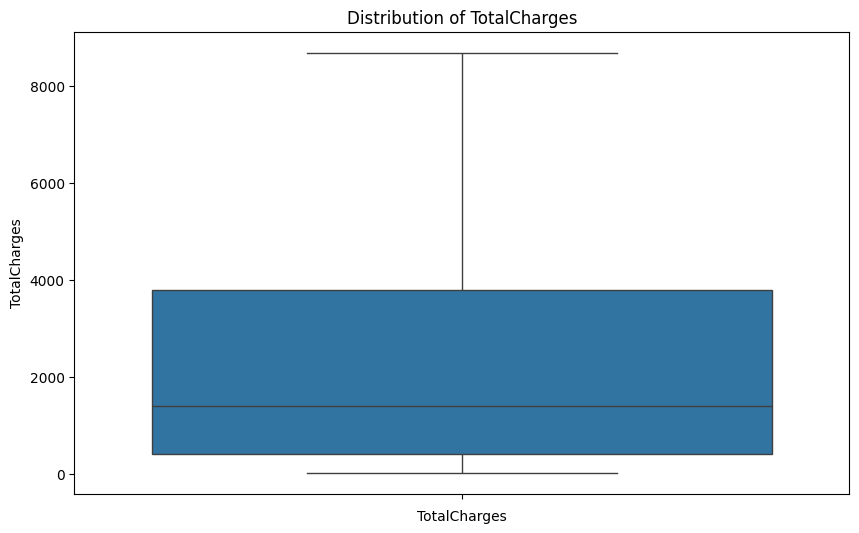

In [45]:
# outliers of Senior Citizens, Tenure, and Monthly Charges
x =['SeniorCitizen', 'tenure', 'MonthlyCharges','TotalCharges']
for i in x:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data[i] , fill=True )
    plt.title(f"Distribution of {i}")
    plt.xlabel(i)


### Segregating variables - Dependent & Independent

In [46]:
x = data.drop(["customerID","Churn"], axis=1)
y = data["Churn"]

## Encoding / scaling the data

In [47]:
from sklearn.preprocessing import OneHotEncoder , StandardScaler


In [48]:
x = pd.get_dummies(x)
x.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,True,False,False,True,True,False,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,False,True,True,False,True,False,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,False,True,True,False,True,False,...,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,False,True,True,False,True,False,...,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,True,False,True,False,True,False,...,False,True,False,False,False,True,False,False,True,False


In [49]:
y = y.map({"Yes":1 , "No":0})

In [50]:
x.isna().sum()

SeniorCitizen                               0
tenure                                      0
MonthlyCharges                              0
TotalCharges                               11
gender_Female                               0
gender_Male                                 0
Partner_No                                  0
Partner_Yes                                 0
Dependents_No                               0
Dependents_Yes                              0
PhoneService_No                             0
PhoneService_Yes                            0
MultipleLines_No                            0
MultipleLines_No phone service              0
MultipleLines_Yes                           0
InternetService_DSL                         0
InternetService_Fiber optic                 0
InternetService_No                          0
OnlineSecurity_No                           0
OnlineSecurity_No internet service          0
OnlineSecurity_Yes                          0
OnlineBackup_No                   

In [51]:
## fill the missing values for TotalCharges with the mean value
x["TotalCharges"] = x["TotalCharges"].fillna(x["TotalCharges"].mean())

In [52]:
s = StandardScaler()
x = s.fit_transform(x)

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
x_train , x_test , y_train ,y_test = train_test_split( x ,y ,random_state=42 , stratify=y)

## Implementing KNN model

In [55]:
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.metrics import f1_score


In [56]:
# Creating instance of KNN
clf = KNN(n_neighbors = 3)

# Fitting the model
clf.fit(x_train, y_train)

# Predicting over the Train Set and calculating F1
train_predict = clf.predict(x_train)
k = f1_score(train_predict, y_train)
print('Training F1 Score', k )

# Predicting over the Train Set and calculating F1
test_predict = clf.predict(x_test)
k = f1_score(test_predict, y_test)
print('Test F1 Score    ', k )



Training F1 Score 0.7229629629629629
Test F1 Score     0.5168776371308017


### Checking the Training F1 and Test F1curve

In [57]:
k_range  = range(1,150)
train_f1_scores = []
test_f1_scores = []
train_RMSE = []
test_RMSE = []
for k in k_range:
    # Creating instance of KNN / euclidien distance
    clf = KNN(n_neighbors = k,
                  metric = "minkowski",
                  weights = "uniform",
                  p=2)

    # Fitting the model
    clf.fit(x_train, y_train)

    # Predicting over the Train Set and calculating F1
    train_predict = clf.predict(x_train)
    k = f1_score(train_predict, y_train)
    train_f1_scores.append(k)
    # Calculating RMSE for the Train Set
    rmse_train = np.sqrt(np.mean((train_predict - y_train) ** 2))
    train_RMSE.append(rmse_train)


    # Predicting over the Train Set and calculating F1
    test_predict = clf.predict(x_test)
    k = f1_score(test_predict, y_test)
    test_f1_scores.append(k)
    # Calculating RMSE for the Test Set
    rmse_test = np.sqrt(np.mean((test_predict - y_test) ** 2))
    test_RMSE.append(rmse_test)


<img src="/home/umoujahid/Telco_Customer_Churn/notebooks/image.png" alt="Drawing" style="width: 600px;" style="height:800px;" align="left">
<img src="/home/umoujahid/Telco_Customer_Churn/notebooks/image1.png" alt="Drawing" style="width: 600px;" style="height:800px;" align="left">

In [61]:
df = pd.DataFrame({"Train F1 Score": train_f1_scores, "Test F1 Score": test_f1_scores} , index= k_range)
df.head()

,Train F1 Score,Test F1 Score
1,0.996078,0.462845
2,0.651923,0.346591
3,0.722963,0.516878
4,0.607493,0.461735
5,0.670663,0.522678


## Visualizing

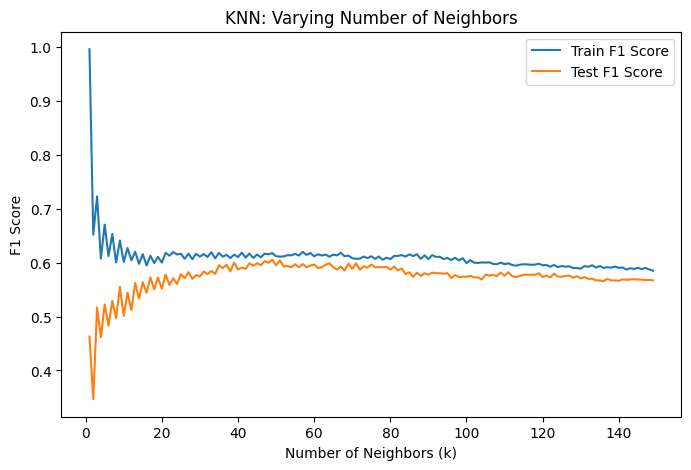

In [62]:
# plotting curves
plt.figure(figsize=(8, 5))
plt.plot(k_range, train_f1_scores, label="Train F1 Score")
plt.plot(k_range, test_f1_scores, label="Test F1 Score")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("F1 Score")
plt.title("KNN: Varying Number of Neighbors")
plt.legend(labels=["Train F1 Score", "Test F1 Score"], loc="upper right")
plt.show()

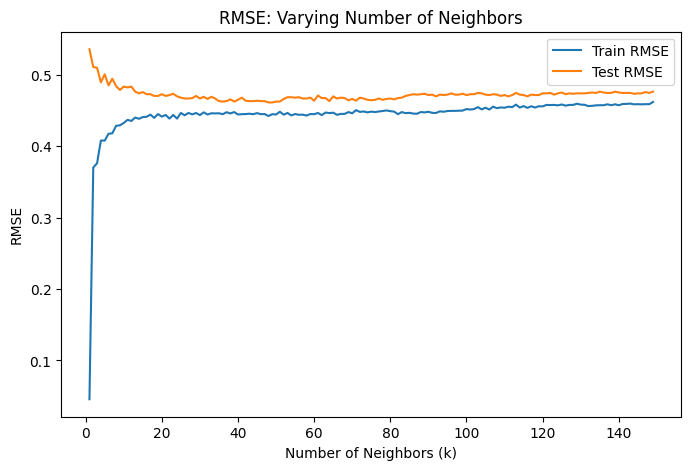

In [64]:
# plotting curves
plt.figure(figsize=(8, 5))
plt.plot(k_range, train_RMSE, label="Train RMSE")
plt.plot(k_range, test_RMSE, label="Test RMSE")
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("RMSE")
plt.title("RMSE: Varying Number of Neighbors")
plt.legend(labels=["Train RMSE", "Test RMSE"], loc="upper right")
plt.show()

In [63]:
# best fit
optimal_k = df["Test F1 Score"].idxmax()
best_fit = np.array(df.loc[df["Test F1 Score"].idxmax()])
print("best value for K :" , optimal_k ,"\nbest result achieved \n( f1 train  , f1 test):\n" , best_fit)


best value for K : 49 
best result achieved 
( f1 train  , f1 test):
 [0.61769006 0.60567823]
